In [5]:
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("../Dataset/final_selected_dataset.csv")

df.head()

,avg_activity_day,login_frequency,video_clicks,avg_quiz_score,avg_submission_day,assessments_completed,avg_assessment_weight,studied_credits,code_module_GGG,highest_education_Lower Than A Level,code_presentation_2014J,code_module_CCC,code_module_EEE,code_module_FFF,code_presentation_2013J,dropout
0,102.132653,196.0,934.0,78.0,18.0,1.0,10.0,240,False,False,False,False,False,False,True,0
1,86.993023,430.0,1435.0,70.0,22.0,1.0,10.0,60,False,False,False,False,False,False,True,0
2,2.355263,76.0,281.0,0.0,0.0,0.0,0.0,60,False,False,False,False,False,False,True,1
3,106.147813,663.0,2158.0,72.0,17.0,1.0,10.0,60,False,False,False,False,False,False,True,0
4,91.934659,352.0,1034.0,69.0,26.0,1.0,10.0,60,False,True,False,False,False,False,True,0


In [7]:
print(df.shape)

df.info()

(32593, 16)
<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   avg_activity_day                      32593 non-null  float64
 1   login_frequency                       32593 non-null  float64
 2   video_clicks                          32593 non-null  float64
 3   avg_quiz_score                        32593 non-null  float64
 4   avg_submission_day                    32593 non-null  float64
 5   assessments_completed                 32593 non-null  float64
 6   avg_assessment_weight                 32593 non-null  float64
 7   studied_credits                       32593 non-null  int64  
 8   code_module_GGG                       32593 non-null  bool   
 9   highest_education_Lower Than A Level  32593 non-null  bool   
 10  code_presentation_2014J               32593 non-null  bool   
 11  code_module_CC

In [8]:
# Remove Unwanted Columns
if "final_result" in df.columns:
    df = df.drop(columns=["final_result"])

df.head()

,avg_activity_day,login_frequency,video_clicks,avg_quiz_score,avg_submission_day,assessments_completed,avg_assessment_weight,studied_credits,code_module_GGG,highest_education_Lower Than A Level,code_presentation_2014J,code_module_CCC,code_module_EEE,code_module_FFF,code_presentation_2013J,dropout
0,102.132653,196.0,934.0,78.0,18.0,1.0,10.0,240,False,False,False,False,False,False,True,0
1,86.993023,430.0,1435.0,70.0,22.0,1.0,10.0,60,False,False,False,False,False,False,True,0
2,2.355263,76.0,281.0,0.0,0.0,0.0,0.0,60,False,False,False,False,False,False,True,1
3,106.147813,663.0,2158.0,72.0,17.0,1.0,10.0,60,False,False,False,False,False,False,True,0
4,91.934659,352.0,1034.0,69.0,26.0,1.0,10.0,60,False,True,False,False,False,False,True,0


In [9]:
# Separate Features and Target
X = df.drop(
    columns=[
        "dropout",
        "registration_days"
    ],
    errors="ignore"
)
y = df["dropout"]

In [10]:
# Identify Categorical Columns
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(categorical_features)

[]


In [11]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [12]:
df["dropout"].value_counts()

dropout
0    22437
1    10156
Name: count, dtype: int64

In [13]:
df = pd.read_csv("../Dataset/final_dataset.csv")

print(df["dropout"].value_counts())

dropout
0    22437
1    10156
Name: count, dtype: int64


In [14]:
df["dropout"].value_counts()
df.head()
import pandas as pd

studentInfo = pd.read_csv("../Dataset/processed/studentInfo_clean.csv")

studentInfo["final_result"].value_counts()
studentInfo["final_result"].unique()

<StringArray>
['Pass', 'Withdrawn', 'Fail', 'Distinction']
Length: 4, dtype: str

In [15]:
studentInfo["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [16]:
# Train CatBoost Model
model = CatBoostClassifier(

    iterations=500,

    learning_rate=0.05,

    depth=6,

    loss_function="Logloss",

    eval_metric="AUC",

    verbose=100,

    random_seed=42

)

model.fit(

    X_train,

    y_train,

    cat_features=categorical_features

)

0:	total: 153ms	remaining: 1m 16s
100:	total: 882ms	remaining: 3.48s
200:	total: 1.63s	remaining: 2.43s
300:	total: 2.31s	remaining: 1.53s
400:	total: 2.94s	remaining: 726ms
499:	total: 3.57s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [17]:
# Prediction
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [18]:
# Accuracy
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.8630157999693204


In [19]:
print(df["dropout"].value_counts())
print(df["dropout"].value_counts(normalize=True))

dropout
0    22437
1    10156
Name: count, dtype: int64
dropout
0    0.688399
1    0.311601
Name: proportion, dtype: float64


In [20]:
print(X.columns.tolist())

['avg_activity_day', 'login_frequency', 'video_clicks', 'avg_quiz_score', 'avg_submission_day', 'assessments_completed', 'avg_assessment_weight', 'studied_credits', 'code_module_GGG', 'highest_education_Lower Than A Level', 'code_presentation_2014J', 'code_module_CCC', 'code_module_EEE', 'code_module_FFF', 'code_presentation_2013J']


In [21]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Training Accuracy :", accuracy_score(y_train, train_pred))
print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

Training Accuracy : 0.8876658740507786
Testing Accuracy  : 0.8630157999693204


In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                                 Feature  Importance
0                       avg_activity_day   50.174924
1                        login_frequency    8.954760
2                           video_clicks    8.923209
4                     avg_submission_day    6.444106
3                         avg_quiz_score    5.706665
7                        studied_credits    4.831138
10               code_presentation_2014J    3.336583
6                  avg_assessment_weight    3.296952
11                       code_module_CCC    2.050094
13                       code_module_FFF    1.312458
14               code_presentation_2013J    1.292511
8                        code_module_GGG    1.238439
5                  assessments_completed    1.207743
9   highest_education_Lower Than A Level    0.837880
12                       code_module_EEE    0.392537


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8630157999693204
Precision : 0.7743490838958534
Recall : 0.7907434761201378
F1 Score : 0.7824604141291108
ROC AUC : 0.9372517314073922

Confusion Matrix
[[4020  468]
 [ 425 1606]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      4488
           1       0.77      0.79      0.78      2031

    accuracy                           0.86      6519
   macro avg       0.84      0.84      0.84      6519
weighted avg       0.86      0.86      0.86      6519



In [24]:
import shap

c:\Users\saran\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
explainer = shap.TreeExplainer(model)

In [26]:
shap_values = explainer.shap_values(X_test)

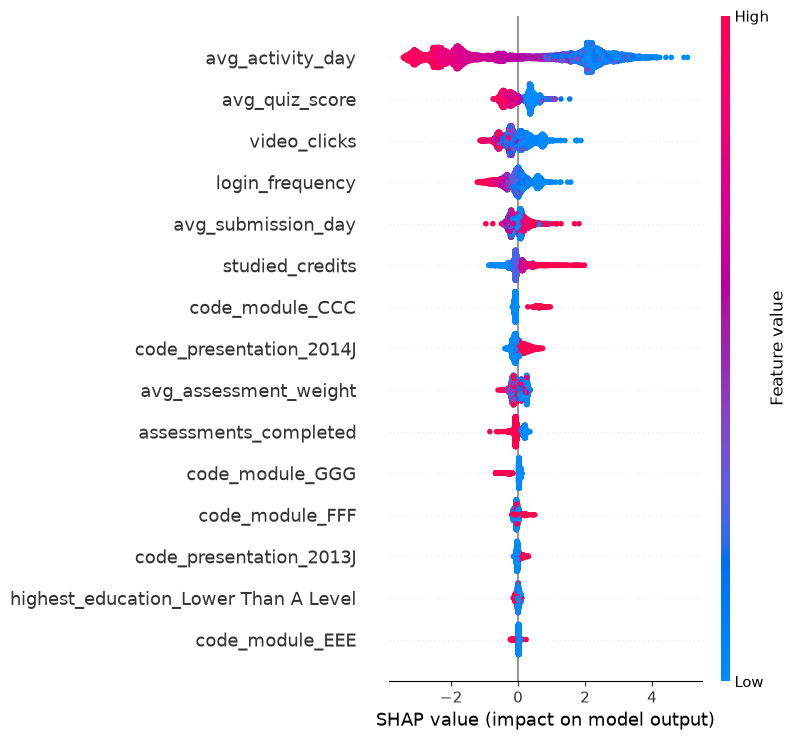

In [27]:
shap.summary_plot(
    shap_values,
    X_test
)

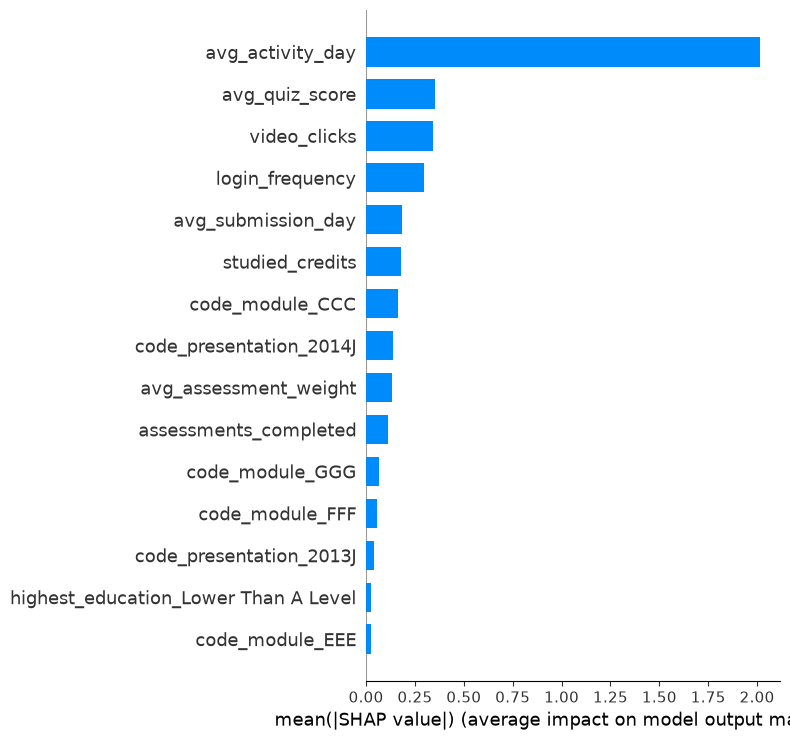

In [28]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [29]:
risk_probability = model.predict_proba(X_test)[:,1]

In [30]:
# Predict for ALL students

all_predictions = model.predict(X)

all_probabilities = model.predict_proba(X)[:, 1]


# Risk Level Function

def classify_risk(prob):

    if prob < 0.30:
        return "Low"

    elif prob < 0.70:
        return "Medium"

    else:
        return "High"


risk_level = [classify_risk(p) for p in all_probabilities]


# Create Result Dataset

results = X.copy()

results.insert(0, "Student ID", range(1, len(results)+1))

results["Actual"] = y.values

results["Predicted"] = all_predictions.astype(int)

results["Risk Probability"] = all_probabilities

results["Risk Level"] = risk_level


print(results.head())

print(results.shape)


results.to_csv(
    "../Dataset/student_risk_prediction.csv",
    index=False
)

print("Student Risk Prediction Dataset Saved Successfully")

   Student ID  avg_activity_day  login_frequency  video_clicks  \
0           1        102.132653            196.0         934.0   
1           2         86.993023            430.0        1435.0   
2           3          2.355263             76.0         281.0   
3           4        106.147813            663.0        2158.0   
4           5         91.934659            352.0        1034.0   

   avg_quiz_score  avg_submission_day  assessments_completed  \
0            78.0                18.0                    1.0   
1            70.0                22.0                    1.0   
2             0.0                 0.0                    0.0   
3            72.0                17.0                    1.0   
4            69.0                26.0                    1.0   

   avg_assessment_weight  studied_credits  code_module_GGG  \
0                   10.0              240            False   
1                   10.0               60            False   
2                    0.0        

In [31]:
print(results.shape)

(32593, 20)


In [35]:
print("df shape :", df.shape)

print("X shape :", X.shape)

print("y shape :", y.shape)

print(df.columns)

df shape : (32593, 20)
X shape : (32593, 15)
y shape : (32593,)
Index(['code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'dropout',
       'avg_quiz_score', 'assessments_completed', 'avg_assessment_weight',
       'avg_submission_day', 'video_clicks', 'login_frequency',
       'avg_activity_day', 'registration_days'],
      dtype='str')


In [37]:
print(pd.read_csv("../Dataset/final_selected_dataset.csv").shape)

print(pd.read_csv("../Dataset/final_dataset.csv").shape)

print(pd.read_csv("../Dataset/final_dataset.csv").columns)

(32593, 16)
(32593, 20)
Index(['code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'dropout',
       'avg_quiz_score', 'assessments_completed', 'avg_assessment_weight',
       'avg_submission_day', 'video_clicks', 'login_frequency',
       'avg_activity_day', 'registration_days'],
      dtype='str')
